In [1]:
import torch
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(0)

### Exercise — A toy regression dataset

Generate a synthetic dataset for the function $y = \sin(2\pi x) + 0.1\,\varepsilon$ with $x \in [0, 1]$ and Gaussian noise $\varepsilon$. Make 1000 training points and 200 validation points. Wrap them in `TensorDataset`s and `DataLoader`s with batch size 32. Use your MyMLP (or the nn.Sequential version) with d_in=1, hidden=64, d_out=1. Train for, say, 200 epochs with MSELoss and torch.optim.Adam(lr=1e-2). Log the average training and validation loss per epoch and plot them. 
On a dense grid of `x` values in `[0, 1]`, predict `y_hat` (under `torch.no_grad()` and in `model.eval()` mode), and plot the predictions against the true sine and the noisy training points.

In [2]:
n_train = 10000
n_val = 200


x_train = torch.rand(n_train, 1)
y_train = torch.sin(2 * torch.pi * x_train) + 0.1 * torch.randn(n_train,1)

x_val = torch.rand(n_val, 1)
y_val = torch.sin(2 * torch.pi * x_val) + 0.1 * torch.randn(n_val,1)


In [3]:
print(x_train.mean(),x_train.std())

tensor(0.5003) tensor(0.2879)


In [4]:
#Dataset??

In [5]:
class MyDataset(Dataset):
    
    def __init__(self, data_inputs, data_labels):
        self.data = data_inputs
        self.label = data_labels

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, index):
        return self.data[index], self.label[index]

In [6]:
train_dataset = MyDataset(x_train,y_train)
val_dataset = MyDataset(x_val,y_val)


In [7]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)


In [8]:
data_inputs, data_labels = next(iter(train_dataloader))
print("x batch shape:", data_inputs.shape)
print("y batch shape:", data_labels.shape)

x batch shape: torch.Size([32, 1])
y batch shape: torch.Size([32, 1])


In [9]:
import torch.nn as nn
#nn.ModuleList??

In [10]:

class MyMLP(nn.Module):
    def __init__(self, act_fn, input_size=1, output_size=1, hidden_sizes=[8, 8]):
        
        super().__init__()
        layer_sizes = [input_size] + hidden_sizes
        
        layers = []
        
        for id in range(1, len(layer_sizes)):
            layers += [nn.Linear(layer_sizes[id-1],layer_sizes[id]), act_fn]
        
        layers += [nn.Linear(layer_sizes[-1],output_size)] # Add last layer no activation here
        self.net = nn.ModuleList(layers)
        #print(self.net)
    def forward(self, x):
        for l in self.net:
            x = l(x)
        return x

In [11]:

model = MyMLP(act_fn=nn.Tanh(),input_size=1,output_size=1,hidden_sizes=[8,8])
print(model.parameters)

# Define Optimiser
#optimiser = torch.optim.SGD(model.parameters(), lr = 0.1, momentum=0)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)

criterion = torch.nn.MSELoss()

from tqdm import tqdm
n_epochs = 100

avg_loss = []
avg_val_loss = []

for epoch in tqdm(range(n_epochs)):
    model.train()
    epoch_loss = 0.0
    for data_input, data_label in train_dataloader:
        ypred = model(data_input)    
        loss = criterion(ypred, data_label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss.append(epoch_loss / len(train_dataloader))
    
    # =========================
    # Validation
    # =========================
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_dataloader:
            ypred_val = model(x_val)
            valloss = criterion(ypred_val, y_val)
            epoch_val_loss += valloss.item()
    avg_val_loss.append(epoch_val_loss / len(val_dataloader))
        

<bound method Module.parameters of MyMLP(
  (net): ModuleList(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)>


100%|█████████████████████████████████████████| 100/100 [00:17<00:00,  5.69it/s]


In [12]:
len(avg_val_loss)

100

/tmp/ipykernel_36989/543913331.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axis1.plot(x,np.sin(2 * torch.pi * x),'r-',label='true sine',linewidth=2)


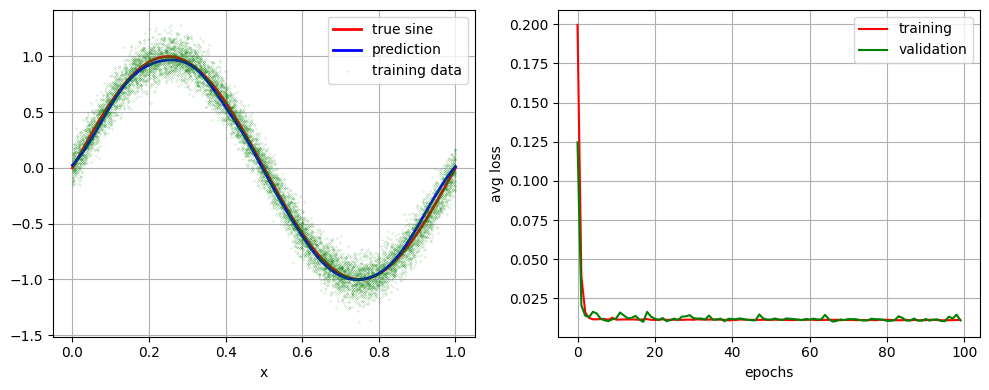

In [13]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(0, 1, n_train)

# Convert to tensor with shape [N,1]
x = torch.tensor(
    x.reshape(-1, 1),
    dtype=torch.float32
)

model.eval()

with torch.no_grad():
    ypred = model(x)
 
fig = plt.figure(figsize=(10,4))
axis1 = fig.add_subplot(1,2,1)
axis1.plot(x,np.sin(2 * torch.pi * x),'r-',label='true sine',linewidth=2)
axis1.plot(x,ypred,'b-',label='prediction',linewidth=2)

axis1.plot(x_train,y_train,'go',label='training data',markersize=0.1)

axis1.set_xlabel('x')
axis1.grid()
axis1.legend()


axis2 = fig.add_subplot(1,2,2)
axis2.plot(np.arange(0,n_epochs),avg_loss,'r-',label='training')
axis2.plot(np.arange(0,n_epochs),avg_val_loss,'g-',label='validation')
axis2.grid()
axis2.set_xlabel('epochs')
axis2.set_ylabel('avg loss')
axis2.legend()

plt.tight_layout()

plt.show()

In [14]:
def visualize_loss(n_epochs, avg_loss = [], avg_val_loss = []):
    
    fig = plt.figure(figsize=(6,4))
    axis = fig.add_subplot(1,1,1)

    if len(avg_loss) > 0:
        axis.plot( np.arange(len(avg_loss)), avg_loss, 'r-', label='training')

    if len(avg_val_loss) > 0:  
        axis.plot( np.arange(len(avg_val_loss)), avg_val_loss, 'g-', label='validation')

    axis.set_xlabel('epochs')
    axis.set_ylabel('avg loss')
    axis.legend()
    axis.grid()
    
    plt.tight_layout()
    return fig


In [16]:
#fig = visualize_loss(n_epochs, avg_loss, avg_val_loss)
#plt.show()

# TensorBoard

In [17]:
#!pip install tensorboard

In [18]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import torch.nn as nn
import torch

writer = SummaryWriter('./runs/simpleMLP')

# Fresh model every run
model = MyMLP(
    act_fn=nn.Tanh(),
    input_size=1,
    output_size=1,
    hidden_sizes=[8,8]
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

criterion = nn.MSELoss()

n_epochs = 100

avg_loss = []
avg_val_loss = []

for epoch in tqdm(range(n_epochs)):

    # =========================
    # Training
    # =========================
    model.train()

    epoch_loss = 0.0

    for data_input, data_label in train_dataloader:

        ypred = model(data_input)
        loss = criterion(ypred, data_label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss = epoch_loss / len(train_dataloader)
    avg_loss.append(train_loss)

    # TensorBoard logging
    writer.add_scalar("Loss/train", train_loss, epoch)

    # =========================
    # Validation
    # =========================
    model.eval()

    epoch_val_loss = 0.0

    with torch.no_grad():
        for x_val, y_val in val_dataloader:
            ypred_val = model(x_val)
            valloss = criterion(ypred_val, y_val)
            epoch_val_loss += valloss.item()
    val_loss = epoch_val_loss / len(val_dataloader)
    avg_val_loss.append(val_loss)

    # TensorBoard logging
    writer.add_scalar("Loss/validation", val_loss, epoch)

# Close AFTER all epochs
writer.close()

100%|█████████████████████████████████████████| 100/100 [00:18<00:00,  5.49it/s]


In [ ]:
!tensorboard --logdir=runs

TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
